#**Parte A**

#Importar los audios

In [2]:
from google.colab import files
files.upload()
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

Saving Mujer-3.wav to Mujer-3.wav
Saving Mujer-2.wav to Mujer-2.wav
Saving Mujer-1.wav to Mujer-1.wav
Saving Hombre-3.wav to Hombre-3.wav
Saving Hombre-2.wav to Hombre-2.wav
Saving Hombre-1.wav to Hombre-1.wav


#Gráfica de las señales

268288 268288


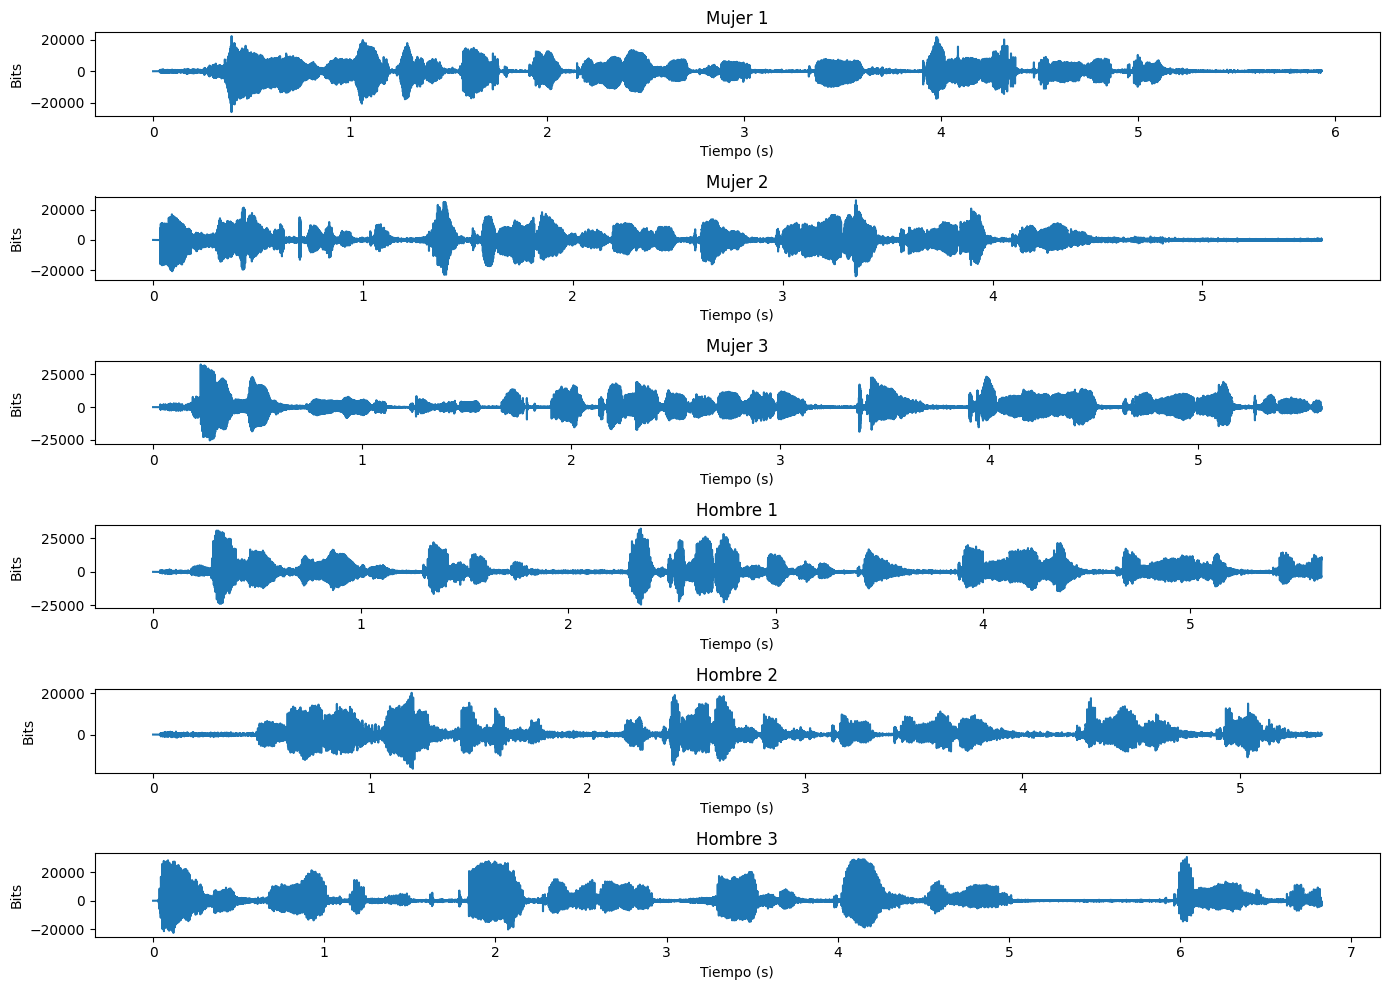

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

# mujeres
fs1,signal1=  wavfile.read('Mujer-1.wav')
fs2,signal2=  wavfile.read('Mujer-2.wav')
fs3,signal3=  wavfile.read('Mujer-3.wav')

# Hombres
fs4,signal4=  wavfile.read('Hombre-1.wav')
fs5,signal5= wavfile.read('Hombre-2.wav')
fs6,signal6= wavfile.read('Hombre-3.wav')


duracion = len(signal1)/fs1

duracion = len(signal2)/fs1

duracion = len(signal3)/fs1


duracion = len(signal4)/fs1

duracion = len(signal5)/fs1

duracion = len(signal6)/fs1


Tiempo1 = np.arange(len(signal1)) / fs1
Tiempo2 = np.arange(len(signal2)) / fs2
Tiempo3 = np.arange(len(signal3)) / fs3
Tiempo4 = np.arange(len(signal4)) / fs4
Tiempo5 = np.arange(len(signal5)) / fs5
Tiempo6 = np.arange(len(signal6)) / fs6
fig, axs = plt.subplots(6,1, figsize=(14,10),sharex=False)

print(len(Tiempo3),len(signal3))

# graficas
axs[0].plot(Tiempo1, signal1)
axs[0].set_title("Mujer 1")
axs[0].set_ylabel('Bits')
axs[0].set_xlabel('Tiempo (s)')

axs[1].plot(Tiempo2, signal2)
axs[1].set_title("Mujer 2")
axs[1].set_ylabel('Bits')
axs[1].set_xlabel('Tiempo (s)')

axs[2].plot(Tiempo3, signal3)
axs[2].set_title("Mujer 3")
axs[2].set_ylabel('Bits')
axs[2].set_xlabel('Tiempo (s)')

axs[3].plot(Tiempo4, signal4)
axs[3].set_title("Hombre 1")
axs[3].set_ylabel('Bits')
axs[3].set_xlabel('Tiempo (s)')

axs[4].plot(Tiempo5, signal5)
axs[4].set_title("Hombre 2")
axs[4].set_ylabel('Bits')
axs[4].set_xlabel('Tiempo (s)')

axs[5].plot(Tiempo6, signal6)
axs[5].set_title("Hombre 3")
axs[5].set_ylabel('Bits')
axs[5].set_xlabel('Tiempo (s)')

plt.tight_layout()
plt.show()


#Transformada de Fourier y espectro de magnitud frecuencial para cada señal

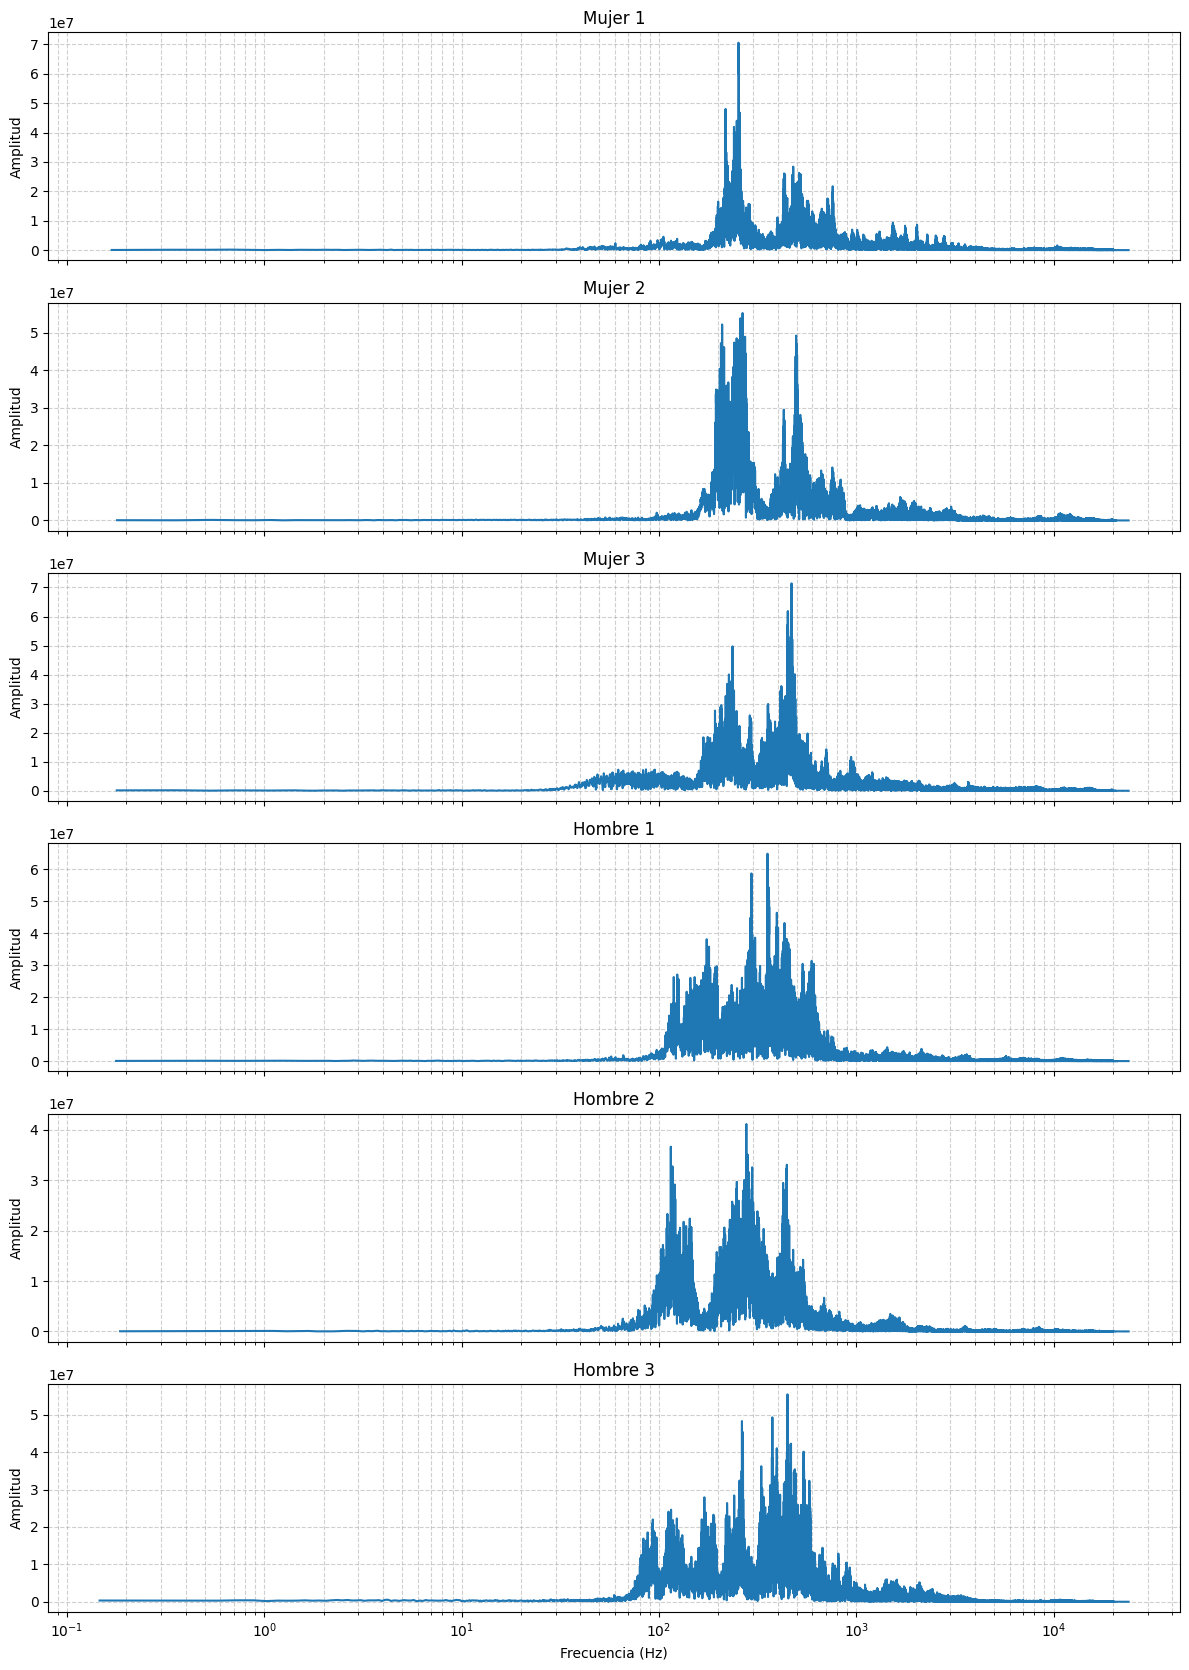

In [7]:
senales = [
    ("Mujer 1", signal1, fs1),
    ("Mujer 2", signal2, fs2),
    ("Mujer 3", signal3, fs3),
    ("Hombre 1", signal4, fs4),
    ("Hombre 2", signal5, fs5),
    ("Hombre 3", signal6, fs6)
]

import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    nrows=len(senales), ncols=1,
    figsize=(12, 2.8*len(senales)),
    sharex=True
)

fny_comun = min(fs/2 for _, _, fs in senales)
ymax = 0.0
espectros = []

for (titulo, senal, fs) in senales:
    N = len(senal)
    freqs = np.fft.rfftfreq(N, 1/fs)
    espectro = np.abs(np.fft.rfft(senal))
    idx = freqs <= fny_comun
    espectros.append((titulo, freqs[idx], espectro[idx]))
    ymax = max(ymax, espectro[idx].max())

for ax, (titulo, F, X) in zip(axes, espectros):
    Fp = F[1:]
    Xp = X[1:]
    ax.semilogx(Fp, Xp)
    ax.set_title(titulo)
    ax.set_ylabel('Amplitud')
    ax.grid(True, which='both', linestyle='--', alpha=0.6)
axes[-1].set_xlabel('Frecuencia (Hz)')

fig.tight_layout(); plt.show()


#Características de la señal

In [8]:
import numpy as np
import pandas as pd
from numpy.fft import rfft, rfftfreq
from scipy.signal import find_peaks


def _to_mono_float(x):
    x = np.asarray(x)
    if x.ndim > 1:
        x = x.mean(axis=1)
    x = x.astype(np.float32)
    x = x - x.mean()
    return x

def analizar_senal(signal, fs):
    sig = _to_mono_float(signal)
    N = len(sig)
    if N == 0 or fs <= 0:
        return 0.0, 0.0, 0.0, 0.0

    X = np.abs(rfft(sig))
    f = rfftfreq(N, d=1.0/fs)

    #Frecuencia fundamental
    mask = f >= 50.0
    Xb = X[mask]
    fb = f[mask]
    if Xb.size and Xb.max() > 0:
        peaks, _ = find_peaks(Xb, height=0.10 * Xb.max())
        if peaks.size:
            f0 = float(fb[peaks[np.argmax(Xb[peaks])]])  #Pico más alto
        else:
            f0 = 0.0
    else:
        f0 = 0.0

    #Frecuencia media
    denom = X.sum()
    f_media = float((f * X).sum() / denom) if denom > 0 else 0.0

    #Brillo
    E_total = float((X**2).sum())
    E_altas = float((X[f > 1500.0]**2).sum())
    brillo = float(E_altas / E_total) if E_total > 0 else 0.0

    #Intensidad
    intensidad = float((sig**2).mean())

    return f0, f_media, brillo, intensidad

nombres = ["Mujer 1","Mujer 2","Mujer 3","Hombre 1","Hombre 2","Hombre 3"]
senales = [signal1, signal2, signal3, signal4, signal5, signal6]
fs_list = [fs1, fs2, fs3, fs4, fs5, fs6]

resultados = []
for nom, sig, fs in zip(nombres, senales, fs_list):
    f0, fmedia, brillo, intensidad = analizar_senal(sig, fs)
    resultados.append([nom, f0, fmedia, brillo, intensidad])

tabla = pd.DataFrame(resultados, columns=["Señal","f0 (Hz)","f_media (Hz)","Brillo","Intensidad"])
print(tabla.to_string(index=False))

   Señal    f0 (Hz)  f_media (Hz)   Brillo  Intensidad
 Mujer 1 253.259892   3731.791957 0.089506  10203768.0
 Mujer 2 265.625000   3660.250096 0.051551  16567467.0
 Mujer 3 470.181298   3690.630463 0.036946  17939960.0
Hombre 1 355.291193   2735.577073 0.017587  20006824.0
Hombre 2 277.529762   2317.599295 0.011562   9058843.0
Hombre 3 448.535156   1982.546529 0.029201  14756064.0


#**Parte B**

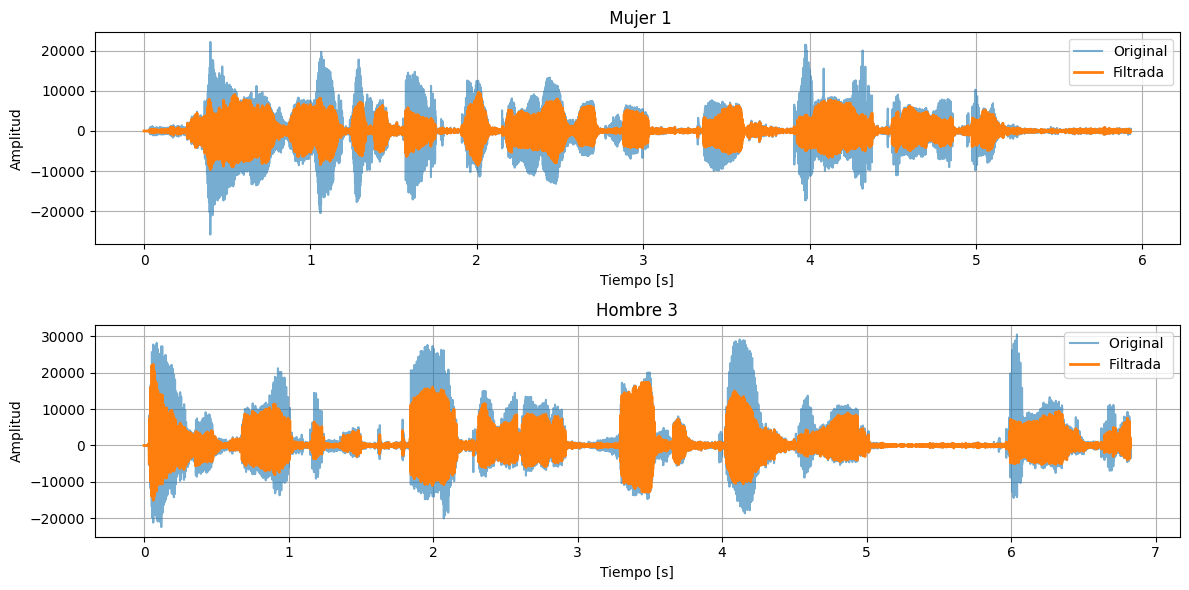

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

def filtro_pasabanda(x, fs, lowcut, highcut, orden):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(orden, [low, high], btype='band')
    return filtfilt(b, a, x)

orden = 3

# Aplicar
mujer1_filtrada = filtro_pasabanda(signal1, fs3, 80, 500, orden)
mujer2_filtrada = filtro_pasabanda(signal2, fs3, 80, 500, orden)
mujer3_filtrada = filtro_pasabanda(signal3, fs3, 80, 500, orden)
hombre1_filtrada = filtro_pasabanda(signal4, fs6, 80, 500, orden)
hombre2_filtrada = filtro_pasabanda(signal5, fs6, 80, 500, orden)
hombre3_filtrada = filtro_pasabanda(signal6, fs6, 80, 500, orden)

# Ejes de tiempo
t_mujer = np.arange(len(signal1)) / fs3
t_hombre = np.arange(len(signal6)) / fs6

plt.figure(figsize=(12,6))

#  MUJER
plt.subplot(2,1,1)
plt.plot(t_mujer, signal1, label="Original", alpha=0.6)
plt.plot(t_mujer, mujer1_filtrada, label="Filtrada", linewidth=2)
plt.title(" Mujer 1")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.legend()
plt.grid()

# HOMBRE
plt.subplot(2,1,2)
plt.plot(t_hombre, signal6, label="Original ", alpha=0.6)
plt.plot(t_hombre, hombre3_filtrada, label="Filtrada ", linewidth=2)
plt.title("Hombre 3")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()



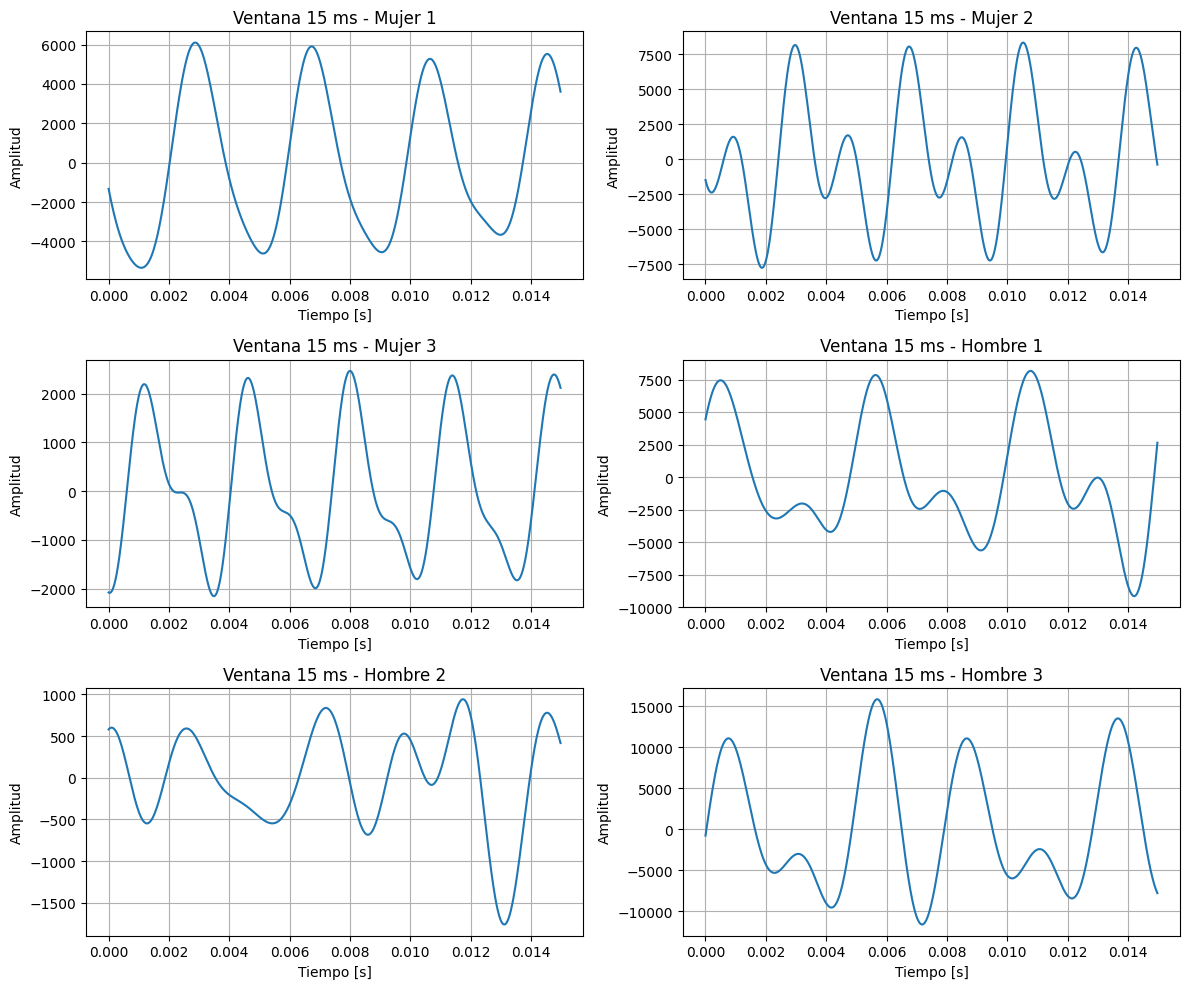

In [55]:
import numpy as np
import matplotlib.pyplot as plt


# Duración ventana

duracion = 0.015  # 15 ms


filtradas = [
    mujer1_filtrada, mujer2_filtrada, mujer3_filtrada,
    hombre1_filtrada, hombre2_filtrada, hombre3_filtrada
]

fs_list = [fs3, fs3, fs3, fs6, fs6, fs6]

nombres = [
    "Mujer 1", "Mujer 2", "Mujer 3",
    "Hombre 1", "Hombre 2", "Hombre 3"
]


#  zonas

tiempos_inicio = [1.0, 1.6, 1.0, 2.6, 2.3, 3.5]


# 4. Grafica de ventanas

plt.figure(figsize=(12,10))

for i, (x, fs, nombre, t_ini) in enumerate(zip(filtradas, fs_list, nombres, tiempos_inicio)):

    N = int(duracion * fs)
    inicio = int(t_ini * fs)

    segmento = x[inicio:inicio + N]
    t = np.arange(len(segmento)) / fs

    plt.subplot(3,2,i+1)
    plt.plot(t, segmento)
    plt.title(f"Ventana 15 ms - {nombre}")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Amplitud")
    plt.grid()

plt.tight_layout()
plt.show()


In [61]:
import numpy as np

def medir_jitter(señal, fs):
    # Convertir a mono si es necesario
    if señal.ndim > 1:
        señal = señal.mean(axis=1)

    # Normalizar para estabilidad
    señal = señal / np.max(np.abs(señal))

    # 1. Detectar cruces por cero positivos (de negativo a positivo)
    cruces = np.where((señal[:-1] < 0) & (señal[1:] >= 0))[0]

    # 2. Calcular periodos Ti (en segundos)
    tiempos_cruce = cruces / fs
    periodos = np.diff(tiempos_cruce)  # T_i = t_(i+1) - t_i

    if len(periodos) < 2:
        return 0.0, 0.0, 0  # no hay suficientes ciclos

    # 3. Calcular jitter absoluto
    jitter_abs = np.mean(np.abs(np.diff(periodos)))  # |T_(i+1) - T_i|

    # 4. Calcular jitter relativo (%)
    T_prom = np.mean(periodos)
    jitter_rel = (jitter_abs / T_prom) * 100

    return jitter_abs, jitter_rel, len(periodos)

# Mujer 3 filtrada
jitter_abs_m1, jitter_rel_m1, N_m1 = medir_jitter(mujer1_filtrada, fs1)
jitter_abs_m2, jitter_rel_m2, N_m2 = medir_jitter(mujer2_filtrada, fs2)
jitter_abs_m3, jitter_rel_m3, N_m3 = medir_jitter(mujer3_filtrada, fs3)

# Hombre 3 filtrada
jitter_abs_h1, jitter_rel_h1, N_h1 = medir_jitter(hombre1_filtrada, fs4)
jitter_abs_h2, jitter_rel_h2, N_h2 = medir_jitter(hombre2_filtrada, fs5)
jitter_abs_h3, jitter_rel_h3, N_h3 = medir_jitter(hombre3_filtrada, fs6)

# --- Imprimir resultados ---
print(f"Mujer 1  - Jitter absoluto: {jitter_abs_m1*1000:.3f} ms, Jitter relativo: {jitter_rel_m1:.2f} % con {N_m1} periodos")
print(f"Mujer 2  - Jitter absoluto: {jitter_abs_m2*1000:.3f} ms, Jitter relativo: {jitter_rel_m2:.2f} % con {N_m2} periodos")
print(f"Mujer 3  - Jitter absoluto: {jitter_abs_m3*1000:.3f} ms, Jitter relativo: {jitter_rel_m3:.2f} % con {N_m3} periodos")

print(f"Hombre 1  - Jitter absoluto: {jitter_abs_h1*1000:.3f} ms, Jitter relativo: {jitter_rel_h1:.2f} % con {N_h1} periodos")
print(f"Hombre 2  - Jitter absoluto: {jitter_abs_h2*1000:.3f} ms, Jitter relativo: {jitter_rel_h2:.2f} % con {N_h2} periodos")
print(f"Hombre 3  - Jitter absoluto: {jitter_abs_h3*1000:.3f} ms, Jitter relativo: {jitter_rel_h3:.2f} % con {N_h3} periodos")

Mujer 1  - Jitter absoluto: 0.755 ms, Jitter relativo: 20.27 % con 1588 periodos
Mujer 2  - Jitter absoluto: 0.631 ms, Jitter relativo: 18.10 % con 1595 periodos
Mujer 3  - Jitter absoluto: 0.759 ms, Jitter relativo: 23.99 % con 1764 periodos
Hombre 1  - Jitter absoluto: 1.002 ms, Jitter relativo: 30.60 % con 1716 periodos
Hombre 2  - Jitter absoluto: 1.197 ms, Jitter relativo: 33.43 % con 1499 periodos
Hombre 3  - Jitter absoluto: 1.104 ms, Jitter relativo: 32.97 % con 2037 periodos


In [59]:
import numpy as np
from scipy.signal import find_peaks

# FUNCIÓN SHIMMER (ABS + REL)

def medir_shimmer(segmento, fs):

    # normalizar
    x = segmento / np.max(np.abs(segmento))
    x = x - np.mean(x)

    # rango voz
    F0_min = 80
    F0_max = 300

    # distancia mínima entre picos
    dist_min = int(fs / F0_max)

    # detectar picos
    peaks, _ = find_peaks(x, distance=dist_min)

    if len(peaks) < 3:
        return None, None, len(peaks)

    # amplitudes
    A = x[peaks]

    # periodos
    T = np.diff(peaks) / fs

    mask = (T >= 1/F0_max) & (T <= 1/F0_min)

    if np.sum(mask) < 2:
        return None, None, len(peaks)

    valid_idx = np.where(mask)[0]
    A_valid = A[np.concatenate(([0], valid_idx + 1))]

    if len(A_valid) < 3:
        return None, None, len(A_valid)


    # SHIMMER ABSOLUTO

    shimmer_abs = np.mean(np.abs(np.diff(A_valid)))


    # SHIMMER RELATIVO (%)

    shimmer_rel = (shimmer_abs / np.mean(A_valid)) * 100

    return shimmer_abs, shimmer_rel, len(A_valid)

duracion = 0.015  # 15 ms

print("------ SHIMMER FINAL ------\n")

for x, fs, nombre, t_ini in zip(filtradas, fs_list, nombres, tiempos_inicio):

    N = int(duracion * fs)
    inicio = int(t_ini * fs)
    segmento = x[inicio:inicio + N]

    shimmer_abs, shimmer_rel, N_ciclos = medir_shimmer(segmento, fs)

    if shimmer_rel is None:
        print(f"{nombre}: ERROR (pocos ciclos: {N_ciclos})\n")
    else:
        print(f"{nombre}:")
        print(f"  Shimmer absoluto = {shimmer_abs:.4f}")
        print(f"  Shimmer relativo = {shimmer_rel:.2f}% ({N_ciclos} ciclos)\n")


------ SHIMMER FINAL ------

Mujer 1:
  Shimmer absoluto = 0.0587
  Shimmer relativo = 6.16% (4 ciclos)

Mujer 2:
  Shimmer absoluto = 0.0300
  Shimmer relativo = 3.08% (4 ciclos)

Mujer 3:
  Shimmer absoluto = 0.0389
  Shimmer relativo = 4.16% (5 ciclos)

Hombre 1:
  Shimmer absoluto = 0.0393
  Shimmer relativo = 4.50% (3 ciclos)

Hombre 2:
  Shimmer absoluto = 0.0968
  Shimmer relativo = 21.19% (3 ciclos)

Hombre 3:
  Shimmer absoluto = 0.2245
  Shimmer relativo = 27.36% (3 ciclos)

